# Prototipo simulador parte 5: integración y correcciones

In [1]:
# Librerías
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Estilo
plt.style.use('seaborn-v0_8-whitegrid')


In [2]:
class Paciente:
    """Clase que define un paciente con parámetros normales;
    para agregar pacientes con patologías, crear una subclase con modificaciones
    en los parámetros específicos que haga falta"""
    def __init__(self, R1=5, C1=0.05, R2=10, C2=0.05):
        self.R1 = R1
        self.C1 = C1
        self.R2 = R2
        self.C2 = C2
        self.E1 = 1 / self.C1
        self.E2 = 1 / self.C2


In [3]:
class Ventilador:
    """Parámetros y perfiles de ventilación mecánica."""
    def __init__(self,
                 modo: str = 'PCV',
                 PEEP: float = 5.0,
                 P_driving: float = 15.0,
                 fr: float = 20.0,
                 Ti: float = 1.0,
                 Vt: float = None):
        self.modo = modo
        self.PEEP = PEEP
        self.P_driving = P_driving
        self.fr = fr
        self.Ti = Ti
        self.T_total = 60.0 / fr
        self.Vt = Vt
        if modo == 'VCV':
            assert Vt is not None, "Se requiere Vt para modo VCV"
            self.flow_insp = Vt / Ti
        else:
            self.flow_insp = None

    def presion(self, t: float) -> np.ndarray:
        """Perfil de presión en la vía aérea según el modo y el tiempo t."""
        t_arr = np.asarray(t) 
        en_insp = (t_arr % self.T_total) < self.Ti
        if self.modo == 'PCV':
            P_control = self.PEEP + self.P_driving
            return np.where(en_insp, P_control, self.PEEP)
        elif self.modo == 'VCV':
            return np.full_like(t_arr, self.PEEP)
        else:
            raise ValueError(f"Modo desconocido: {self.modo}")

    def flujo(self, t: float) -> np.ndarray:
        """Perfil de flujo inspirado en VCV, 0 fuera de inspiración."""
        if self.modo != 'VCV':
            return np.zeros_like(np.asarray(t))
        t_arr = np.asarray(t)
        return np.where((t_arr % self.T_total) < self.Ti, self.flow_insp, 0.0)


In [4]:
class Simulador:
    """Orquesta la simulación paciente-ventilador."""
    def __init__(self,
                 paciente: Paciente,
                 ventilador: Ventilador,
                 control: 'ControlRespiratorio' = None):
        self.paciente = paciente
        self.ventilador = ventilador
        self.control = control
        if ventilador.modo == 'ESP':
            assert self.control is not None, "Se requiere un módulo de ControlRespiratorio para el modo 'ESP'"

    def _modelo_edo(self, t, y):
        V1, V2 = y
        R_exp = 5.0
        en_insp = (t % self.ventilador.T_total) < self.ventilador.Ti

        if self.ventilador.modo == 'ESP':
            # FIX 1: P_aw incluye PEEP como baseline; Pmus es la presión muscular adicional.
            # Sin esto, el equilibrio espiratorio era V=0 en lugar de PEEP/E.
            # FIX 2b: P_aw = PEEP - Pmus porque Pmus < 0 durante inspiración (convención
            # de succión diafragmática). Restar Pmus negativo eleva P_aw por encima de PEEP,
            # lo que genera el volumen tidal correcto.
            Pmus = self.control.generar_Pmus(t)
            P_aw = self.ventilador.PEEP - Pmus
            dV1_dt = (P_aw - self.paciente.E1 * V1) / self.paciente.R1
            dV2_dt = (P_aw - self.paciente.E2 * V2) / self.paciente.R2

        elif self.ventilador.modo in ['VCV', 'PCV']:
            if en_insp:
                if self.ventilador.modo == 'VCV':
                    flow_total = self.ventilador.flow_insp
                    P_aw = (flow_total + (self.paciente.E1 * V1 / self.paciente.R1) + (self.paciente.E2 * V2 / self.paciente.R2)) / ((1.0 / self.paciente.R1) + (1.0 / self.paciente.R2))
                else: # PCV
                    P_aw = self.ventilador.PEEP + self.ventilador.P_driving
                
                dV1_dt = (P_aw - self.paciente.E1 * V1) / self.paciente.R1
                dV2_dt = (P_aw - self.paciente.E2 * V2) / self.paciente.R2
            else:
                # Fase Espiratoria: Descarga pasiva compartida a través de R_exp
                A = self.ventilador.PEEP - self.paciente.E1 * V1
                B = self.ventilador.PEEP - self.paciente.E2 * V2
                R1, R2 = self.paciente.R1, self.paciente.R2
                
                D = R1 * R2 + R1 * R_exp + R2 * R_exp
                dV1_dt = (A * (R2 + R_exp) - B * R_exp) / D
                dV2_dt = (B * (R1 + R_exp) - A * R_exp) / D
        else:
            raise ValueError(f"Modo desconocido: {self.ventilador.modo}")

        return [dV1_dt, dV2_dt]

    def _edo_insp(self, t, y):
        """EDO fase inspiratoria: solo se llama en [t0, Ti]."""
        V1, V2 = y
        pac = self.paciente
        vent = self.ventilador
        if vent.modo == 'VCV':
            flow = vent.flow_insp
            P_aw = (flow + pac.E1*V1/pac.R1 + pac.E2*V2/pac.R2) / (1/pac.R1 + 1/pac.R2)
        else:  # PCV
            P_aw = vent.PEEP + vent.P_driving
        return [(P_aw - pac.E1*V1)/pac.R1,
                (P_aw - pac.E2*V2)/pac.R2]

    def _edo_esp(self, t, y):
        """EDO fase espiratoria con R_exp compartido: solo se llama en [Ti, T_total]."""
        V1, V2 = y
        pac = self.paciente
        vent = self.ventilador
        R_exp = 5.0
        A = vent.PEEP - pac.E1*V1
        B = vent.PEEP - pac.E2*V2
        D = pac.R1*pac.R2 + pac.R1*R_exp + pac.R2*R_exp
        return [(A*(pac.R2+R_exp) - B*R_exp)/D,
                (B*(pac.R1+R_exp) - A*R_exp)/D]

    def simular(self,
                num_ciclos: int=15,
                pasos_por_ciclo: int = 100):
        """Ejecuta múltiples ciclos y devuelve t, V1 y V2 concatenados."""
        t_data, V1_data, V2_data = [], [], []
        V0 = [0.0, 0.0]

        if self.ventilador.modo == 'ESP':
            # ESP: Pmus es continua, integración unificada por ciclo
            for i in range(num_ciclos):
                t0 = i * self.ventilador.T_total
                t1 = (i + 1) * self.ventilador.T_total
                t_eval = np.linspace(t0, t1, pasos_por_ciclo, endpoint=(i == num_ciclos-1))
                sol = solve_ivp(self._modelo_edo, [t0, t1], V0, t_eval=t_eval)
                t_data.append(sol.t)
                V1_data.append(sol.y[0])
                V2_data.append(sol.y[1])
                V0 = sol.y[:, -1]
        else:
            # PCV/VCV: integración dividida en Ti para no cruzar la discontinuidad
            # de las ecuaciones (insp vs esp tienen física distinta).
            for i in range(num_ciclos):
                t0   = i * self.ventilador.T_total
                t_Ti = t0 + self.ventilador.Ti
                t1   = t0 + self.ventilador.T_total
                n_insp = max(10, int(pasos_por_ciclo * self.ventilador.Ti / self.ventilador.T_total))
                n_esp  = max(10, pasos_por_ciclo - n_insp)

                t_eval_i = np.linspace(t0, t_Ti, n_insp, endpoint=False)
                sol_i = solve_ivp(self._edo_insp, [t0, t_Ti], V0,
                                  t_eval=t_eval_i, method='RK45', max_step=0.05)

                V_mid = sol_i.y[:, -1]
                t_eval_e = np.linspace(t_Ti, t1, n_esp, endpoint=(i == num_ciclos-1))
                sol_e = solve_ivp(self._edo_esp, [t_Ti, t1], V_mid,
                                  t_eval=t_eval_e, method='RK45', max_step=0.05)

                t_data.extend([sol_i.t, sol_e.t])
                V1_data.extend([sol_i.y[0], sol_e.y[0]])
                V2_data.extend([sol_i.y[1], sol_e.y[1]])
                V0 = sol_e.y[:, -1]

        return np.concatenate(t_data), np.concatenate(V1_data), np.concatenate(V2_data)

    def procesar_resultados(self, t: np.ndarray, V1: np.ndarray, V2: np.ndarray) -> dict:
        """Calcula flujo, volumen total y presión resultante."""
        Vt = V1 + V2
        R_exp = 5.0
        en_insp = (t % self.ventilador.T_total) < self.ventilador.Ti

        if self.ventilador.modo in ['PCV', 'VCV']:
            # FIX 3: flujo analítico desde las ecuaciones del modelo.
            # np.gradient introduce spikes en el boundary Ti y curvas espiratorias
            # no-monótonas; el flujo analítico es la fuente de verdad.
            pac = self.paciente
            vent = self.ventilador
            if vent.modo == 'VCV':
                flow_ctrl = vent.flow_insp * np.ones_like(t)
                P_aw_i = (flow_ctrl + pac.E1*V1/pac.R1 + pac.E2*V2/pac.R2) / (1/pac.R1 + 1/pac.R2)
            else:
                P_aw_i = np.full_like(t, vent.PEEP + vent.P_driving)
            f1_i = (P_aw_i - pac.E1*V1) / pac.R1
            f2_i = (P_aw_i - pac.E2*V2) / pac.R2
            A = vent.PEEP - pac.E1*V1
            B = vent.PEEP - pac.E2*V2
            D = pac.R1*pac.R2 + pac.R1*R_exp + pac.R2*R_exp
            f1_e = (A*(pac.R2+R_exp) - B*R_exp) / D
            f2_e = (B*(pac.R1+R_exp) - A*R_exp) / D
            flujo1 = np.where(en_insp, f1_i, f1_e)
            flujo2 = np.where(en_insp, f2_i, f2_e)
        else:
            flujo1 = np.gradient(V1, t)
            flujo2 = np.gradient(V2, t)
        flujo_total = flujo1 + flujo2
        
        # Cálculo de presiones por fase usando vectorización
        P_aw_esp = self.ventilador.PEEP - (flujo_total * R_exp) # El flujo es negativo en espiración
        P_aw_insp_vcv = (flujo_total + (self.paciente.E1 * V1 / self.paciente.R1) + (self.paciente.E2 * V2 / self.paciente.R2)) / ((1.0 / self.paciente.R1) + (1.0 / self.paciente.R2))
        P_aw_insp_pcv = self.ventilador.PEEP + self.ventilador.P_driving
        
        if self.ventilador.modo == 'VCV':
            P_aw = np.where(en_insp, P_aw_insp_vcv, P_aw_esp)
        elif self.ventilador.modo == 'PCV':
            P_aw = np.where(en_insp, P_aw_insp_pcv, P_aw_esp)
        else:
            P_aw = np.zeros_like(t) # Placeholder para 'ESP'

        return {
            't': t, 'V1': V1, 'V2': V2, 'Vt': Vt,
            'flow1': flujo1, 'flow2': flujo2, 'flow': flujo_total, 'P_aw': P_aw
        }

    def graficar_resultados(self,
                            resultados: dict,
                            titulo: str = 'Simulación Pulmonar'):
        """Grafica presión, flujo total y volumen total a partir del diccionario
        de resultados."""
        t = resultados['t']
        P_aw = resultados['P_aw']
        flujo = resultados['flow']
        Vt = resultados['Vt']

        fig, axs = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
        fig.suptitle(titulo, fontsize=16)

        # Presión
        axs[0].plot(t, P_aw, color='red', label='Presión (P_aw)')
        axs[0].set_ylabel('Presión (cmH2O)')
        axs[0].legend()

        # Flujo
        axs[1].plot(t, flujo, color='blue', label='Flujo Total')
        axs[1].set_ylabel('Flujo (L/s)')
        axs[1].axhline(0, color='grey', linewidth=0.8)
        axs[1].legend()

        # Volumen
        axs[2].plot(t, Vt, color='green', label='Volumen (L)')
        axs[2].set_ylabel('Volumen (L)')
        axs[2].set_xlabel('Tiempo (s)')
        axs[2].legend()

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()


In [5]:
class IntercambioGases:
    """
    Módulo de intercambio gaseoso alveolar.
    Calcula presiones de CO2 y O2 alveolares a partir de los resultados
    de la simulación de mecánica respiratoria.
    """
    def __init__(
        self,
        ventilador,
        V_D: float,
        VCO2: float,
        R: float,
        FiO2: float,
        Pb: float,
        PH2O: float = 47.0,
        K: float = 0.863
    ):
        self.ventilador = ventilador
        self.V_D = V_D      # volumen muerto anatómico (L)
        self.VCO2 = VCO2    # producción de CO2 (mL/min)
        self.R = R          # cociente respiratorio (adimensional)
        self.FiO2 = FiO2    # fracción inspirada de O2 (0-1)
        self.Pb = Pb        # presión barométrica (mmHg)
        self.PH2O = PH2O    # presión vapor de agua a 37°C (mmHg)
        self.K = K          # constante de conversión de unidades

    def calcular(self, resultados: dict) -> dict:
        """
        Ejecuta el cálculo de intercambio gaseoso.

        Parámetros
        ----------
        resultados : dict
            Diccionario de salida de Simulador.procesar_resultados(),
            con claves 't' (tiempo) y 'Vt' (volumen total alveolar, L).

        Devuelve
        -------
        dict con:
            VE_min: ventilación minuto total (L/min)
            VA_min: ventilación minuto alveolar (L/min)
            PACO2_mmHg: presión alveolar de CO2 (mmHg)
            PAO2_mmHg: presión alveolar de O2 (mmHg)
        """
        t = resultados['t']
        # 1. Frecuencia respiratoria (ciclos/min)
        f = self.ventilador.fr

        # 2. Volumen tidal (L)
        if self.ventilador.modo == 'VCV':
            VT = self.ventilador.Vt
        else:
            # Para modos espontáneos o PCV, calculamos el VT promedio
            # integrando el flujo inspiratorio sobre el período de simulación.
            flujo = resultados['flow']

            # 1. Identificar el flujo inspiratorio
            flujo_inspiratorio = np.maximum(0, flujo)

            # 2. Integrar el flujo para obtener el volumen total inspirado en el chunk
            volumen_inspirado_total = np.trapz(flujo_inspiratorio, t)

            # 3. Calcular el número de respiraciones en el chunk
            duracion_chunk = t[-1] - t[0]
            num_respiraciones = duracion_chunk * (f / 60.0) # f está en rpm, t en seg

            # 4. Calcular el VT promedio (evitando división por cero)
            if num_respiraciones > 0:
                VT = volumen_inspirado_total / num_respiraciones
            else:
                VT = 0

            # --- INICIO DE BLOQUE DE DEPURACIÓN ---
            print(f"    [DEBUG] Vol. Inspirado Total: {volumen_inspirado_total:.3f} L")
            print(f"    [DEBUG] Num. Respiraciones: {num_respiraciones:.2f}")
            print(f"    [DEBUG] VT Promedio Calculado: {VT:.3f} L")
            # --- FIN DE BLOQUE DE DEPURACIÓN ---

        # 3. Ventilaciones minuto
        VE = VT * f
        VA = (VT - self.V_D) * f

        # --- DEPURACIÓN ADICIONAL ---
        print(f"    [DEBUG] Ventilación Alveolar (VA): {VA:.2f} L/min")
        # --- FIN DE DEPURACIÓN ---

        if VA <= 0:  #ocurre sólo si el VT es realmente muy bajo.
            raise ValueError("Ventilación alveolar ≤ 0, revisa V_D o simulación.")

        # 4. Presión alveolar de CO2 (mmHg)
        PACO2 = (self.VCO2 * self.K) / VA

        # 5. Presión alveolar de O2 (mmHg)
        PIO2 = self.FiO2 * (self.Pb - self.PH2O)
        PAO2 = PIO2 - (PACO2 / self.R)

        return {
            'VE_min': VE,
            'VA_min': VA,
            'PACO2_mmHg': PACO2,
            'PAO2_mmHg': PAO2
        }


In [6]:
class InteraccionCorazonPulmon:
    """
    Módulo de interacción corazón-pulmón.

    Modela el efecto de la presión en la vía aérea sobre el gasto cardíaco y la
    entrega de oxígeno.
    """
    def __init__(
        self,
        GC_base_L_min: float = 5.0,
        k_sensibilidad: float = 0.1,
        hb_g_dl: float = 15.0
    ):
        self.GC_base_L_min = GC_base_L_min
        self.k_sensibilidad = k_sensibilidad
        self.hb_g_dl = hb_g_dl
        # Constantes fisiológicas
        self.O2_CAP_HB = 1.34  # Capacidad de O2 por gramo de Hb (mL O2/g Hb)
        self.O2_SOL_PLASMA = 0.003  # Solubilidad de O2 en plasma (mL O2/dL/mmHg)

    def _estimar_sao2(self, pao2: float) -> float:
        """
        Estima la SaO2 a partir de la PaO2 usando la ecuación empírica de Severinghaus,
        que modela la curva de disociación sigmoide de la hemoglobina.
        Retorna un valor fraccionario (0.0 a 1.0).
        """
        # Se evita el cero absoluto para prevenir errores de división
        p = max(pao2, 0.1)
        sao2 = 1.0 / ((23400.0 / (p**3 + 150.0 * p)) + 1.0)
        return sao2

    def calcular(
        self,
        resultados_mecanica: dict,
        resultados_gases: dict,
        ventilador: Ventilador
    ) -> dict:
        """Calcula el impacto hemodinámico de la ventilación mecánica."""
        t = resultados_mecanica['t']
        P_aw = resultados_mecanica['P_aw']
        PAO2_mmHg = resultados_gases['PAO2_mmHg']

        # 1. Calcular Presión Media en la Vía Aérea (P_mean)
        # Se usa el T_total del ventilador para aislar exactamente el último ciclo
        tiempo_total_ciclo = ventilador.T_total
        p_aw_ultimo_ciclo = P_aw[t >= (t[-1] - tiempo_total_ciclo)]
        t_ultimo_ciclo = t[t >= (t[-1] - tiempo_total_ciclo)]

        area_bajo_curva = np.trapz(p_aw_ultimo_ciclo, t_ultimo_ciclo)
        P_mean = area_bajo_curva / (t_ultimo_ciclo[-1] - t_ultimo_ciclo[0])

        # 2. Calcular Gasto Cardíaco Actual
        PEEP_base = ventilador.PEEP
        delta_p = P_mean - PEEP_base
        reduccion_gc = self.k_sensibilidad * delta_p
        GC_actual = self.GC_base_L_min - reduccion_gc
        
        # Asegurar que el GC no sea negativo
        GC_actual = max(0, GC_actual)

        # 3. Calcular Contenido Arterial de O2 (CAO2)
        # Se asume un gradiente Alveolo-arterial de O2 de 10 mmHg
        PaO2 = PAO2_mmHg - 10.0
        SaO2 = self._estimar_sao2(PaO2)

        # CAO2 = (Hb * SaO2 * 1.34) + (PaO2 * 0.003)
        O2_unido_hb = self.hb_g_dl * SaO2 * self.O2_CAP_HB
        O2_disuelto = PaO2 * self.O2_SOL_PLASMA
        CAO2_ml_dl = O2_unido_hb + O2_disuelto

        # 4. Entrega de Oxígeno (DO2)
        # DO2 (mL/min) = GC (L/min) * CAO2 (mL/dL) * 10 (dL/L)
        DO2_ml_min = GC_actual * CAO2_ml_dl * 10.0

        return {
            'P_mean_cmH2O': P_mean,
            'GC_actual_L_min': GC_actual,
            'PaO2_mmHg': PaO2,
            'SaO2_percent': SaO2 * 100.0,
            'CAO2_ml_dl': CAO2_ml_dl,
            'DO2_ml_min': DO2_ml_min
        }


In [7]:
class ControlRespiratorio:
    """
    Modelo de control respiratorio Proporcional-Integral (PI).

    Ajusta la amplitud y frecuencia de la presión muscular (P_mus)
    en función del error entre la PaCO2 actual (aproximada como PACO2)
    y un valor de referencia (PACO2_target).

    Ecuaciones:
        A = Gp * (PACO2 - PACO2_target)
        f = f_base + Gf * (PACO2 - PACO2_target)

    Métodos
    -------
    actualizar(PACO2)
        Calcula amplitud y frecuencia actuales del P_mus.
    generar_Pmus(t)
        Genera la señal P_mus(t) = A * sin(2π f t).
    """
    def __init__(self,
                 PACO2_target: float = 40.0,
                 f_base: float = 12.0,
                 Gp: float = 0.3,
                 Gf: float = 0.1,
                 Gi: float = 0.05):
        # Valor de referencia de PaCO2 (mmHg)
        self.PACO2_target = PACO2_target
        # Frecuencia respiratoria basal (ciclos/min)
        self.f_base = f_base
        # Ganancia para amplitud de P_mus (cmH2O por mmHg)
        self.Gp = Gp
        # Ganancia para frecuencia respiratoria (Hz por mmHg)
        # Convertir Gf de (ciclos/min)/mmHg a Hz/mmHg: Gf/60
        self.Gf = Gf / 60.0
        self.Gi = Gi  # Ganancia Integral
        self.integral_error = 0.0 # Acumulador del error
        # Variables de estado
        self.amplitud = None
        self.frecuencia = None

    def actualizar(self, PACO2: float, dt: float):
        """
        Actualiza la amplitud y frecuencia de P_mus en base a la PACO2.
        """
        error = PACO2 - self.PACO2_target
        # Actualizar el término integral
        self.integral_error += error * dt
        # Limitar el término integral para evitar "wind-up"
        self.integral_error = min(max(self.integral_error, -50.0), 50.0)

        # Salida del controlador = Término P + Término I
        amplitud_calculada = (self.Gp * error) + (self.Gi * self.integral_error)
        self.amplitud = min(max(0.0, amplitud_calculada), 25.0)

        self.frecuencia = max(0.1, self.f_base/60.0 + self.Gf * error)
        return self.amplitud, self.frecuencia

    def generar_Pmus(self, t: np.ndarray) -> np.ndarray:
        """
        Genera la señal de presión muscular.
        P_mus(t) = A * sin(2π f t)
        La presión es solo negativa (inspiración) y cero durante la espiración
        pasiva.

        Parámetros
        ----------
        t : np.ndarray Vector de tiempos en segundos.

        Retorna
        -------
        np.ndarray Señal P_mus en cmH2O.
        """
        if self.amplitud is None or self.frecuencia is None:
            raise RuntimeError("Primero debe llamar a actualizar(PACO2)")
        omega = 2 * np.pi * self.frecuencia

        return -self.amplitud * np.maximum(0, np.sin(omega * t))


## Implementación

### Prueba 1

Paciente sano


--- Iniciando simulación en modo: VCV ---
    [DEBUG] Ventilación Alveolar (VA): 4.50 L/min
    [DEBUG] Ventilación Alveolar (VA): 4.50 L/min
    [DEBUG] Ventilación Alveolar (VA): 4.50 L/min
    [DEBUG] Ventilación Alveolar (VA): 4.50 L/min
    [DEBUG] Ventilación Alveolar (VA): 4.50 L/min
    [DEBUG] Ventilación Alveolar (VA): 4.50 L/min
    [DEBUG] Ventilación Alveolar (VA): 4.50 L/min
    [DEBUG] Ventilación Alveolar (VA): 4.50 L/min
    [DEBUG] Ventilación Alveolar (VA): 4.50 L/min
    [DEBUG] Ventilación Alveolar (VA): 4.50 L/min


/var/folders/fj/m5l0ynr5059cvdqxm37ypbmc0000gn/T/ipykernel_40642/1905150112.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


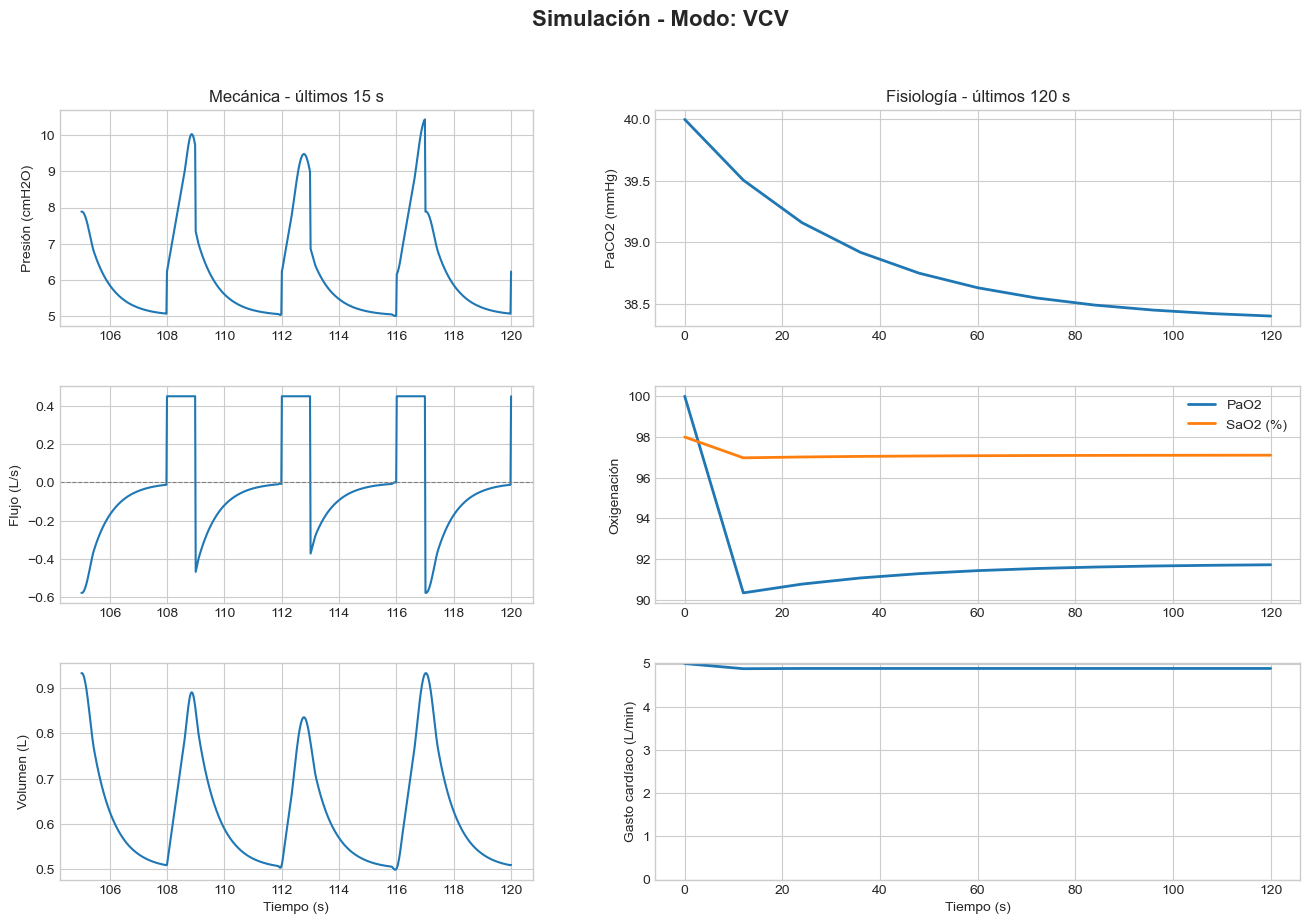


--- Iniciando simulación en modo: PCV ---
    [DEBUG] Vol. Inspirado Total: 3.864 L
    [DEBUG] Num. Respiraciones: 3.00
    [DEBUG] VT Promedio Calculado: 1.288 L
    [DEBUG] Ventilación Alveolar (VA): 17.07 L/min
    [DEBUG] Vol. Inspirado Total: 3.402 L
    [DEBUG] Num. Respiraciones: 3.00
    [DEBUG] VT Promedio Calculado: 1.134 L
    [DEBUG] Ventilación Alveolar (VA): 14.76 L/min
    [DEBUG] Vol. Inspirado Total: 3.401 L
    [DEBUG] Num. Respiraciones: 3.00
    [DEBUG] VT Promedio Calculado: 1.134 L
    [DEBUG] Ventilación Alveolar (VA): 14.76 L/min
    [DEBUG] Vol. Inspirado Total: 3.401 L
    [DEBUG] Num. Respiraciones: 3.00
    [DEBUG] VT Promedio Calculado: 1.134 L
    [DEBUG] Ventilación Alveolar (VA): 14.76 L/min
    [DEBUG] Vol. Inspirado Total: 3.401 L
    [DEBUG] Num. Respiraciones: 3.00
    [DEBUG] VT Promedio Calculado: 1.134 L
    [DEBUG] Ventilación Alveolar (VA): 14.76 L/min
    [DEBUG] Vol. Inspirado Total: 3.401 L
    [DEBUG] Num. Respiraciones: 3.00
    [DEBUG] V

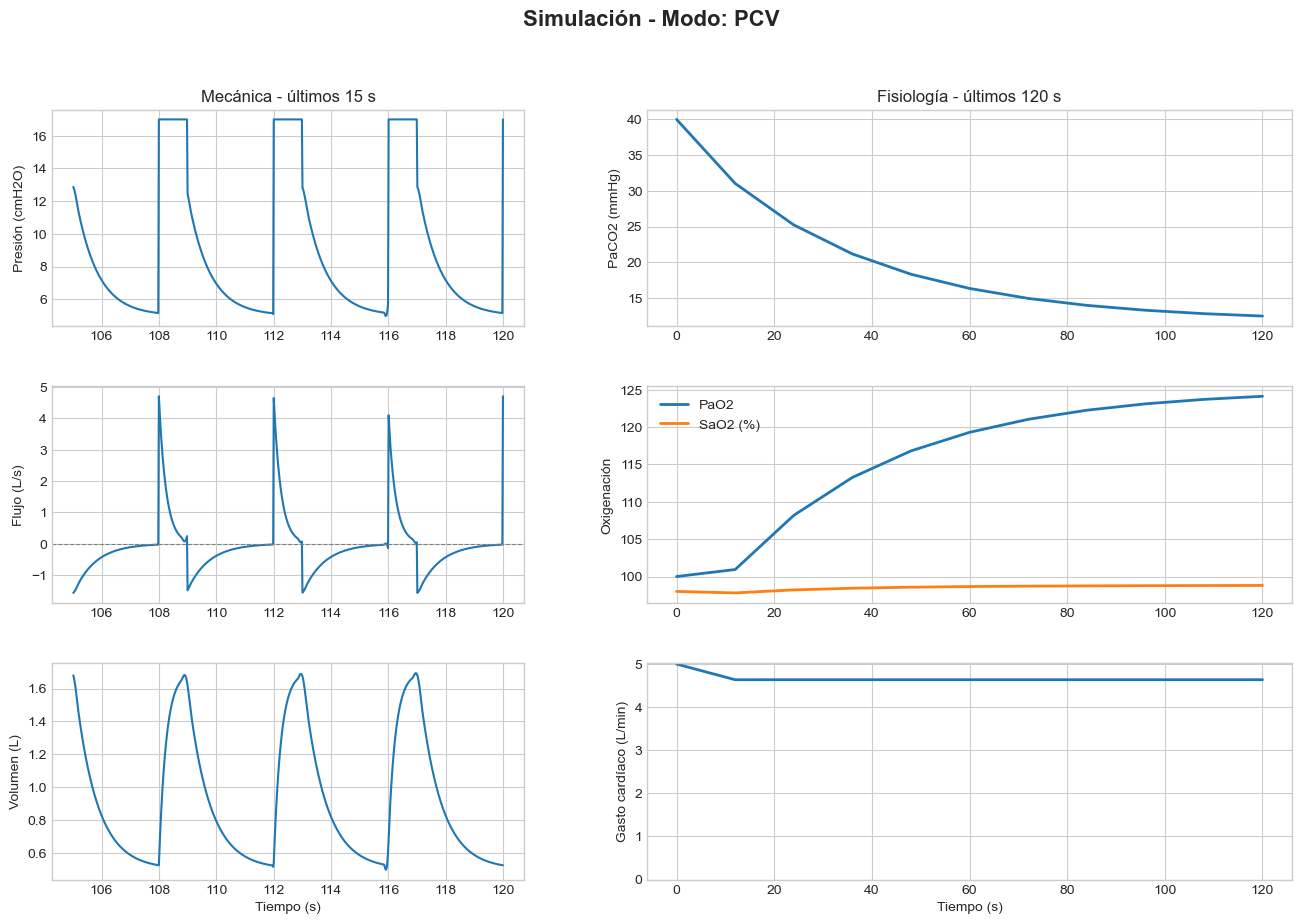


--- Iniciando simulación en modo: ESP ---
    [DEBUG] Vol. Inspirado Total: 0.505 L
    [DEBUG] Num. Respiraciones: 3.00
    [DEBUG] VT Promedio Calculado: 0.168 L
    [DEBUG] Ventilación Alveolar (VA): 0.28 L/min
    [DEBUG] Vol. Inspirado Total: 4.753 L
    [DEBUG] Num. Respiraciones: 3.00
    [DEBUG] VT Promedio Calculado: 1.584 L
    [DEBUG] Ventilación Alveolar (VA): 72.06 L/min
    [DEBUG] Vol. Inspirado Total: 5.426 L
    [DEBUG] Num. Respiraciones: 3.00
    [DEBUG] VT Promedio Calculado: 1.809 L
    [DEBUG] Ventilación Alveolar (VA): 62.05 L/min
    [DEBUG] Vol. Inspirado Total: 6.173 L
    [DEBUG] Num. Respiraciones: 3.00
    [DEBUG] VT Promedio Calculado: 2.058 L
    [DEBUG] Ventilación Alveolar (VA): 54.29 L/min
    [DEBUG] Vol. Inspirado Total: 6.232 L
    [DEBUG] Num. Respiraciones: 3.00
    [DEBUG] VT Promedio Calculado: 2.077 L
    [DEBUG] Ventilación Alveolar (VA): 42.81 L/min
    [DEBUG] Vol. Inspirado Total: 2.663 L
    [DEBUG] Num. Respiraciones: 3.00
    [DEBUG] VT

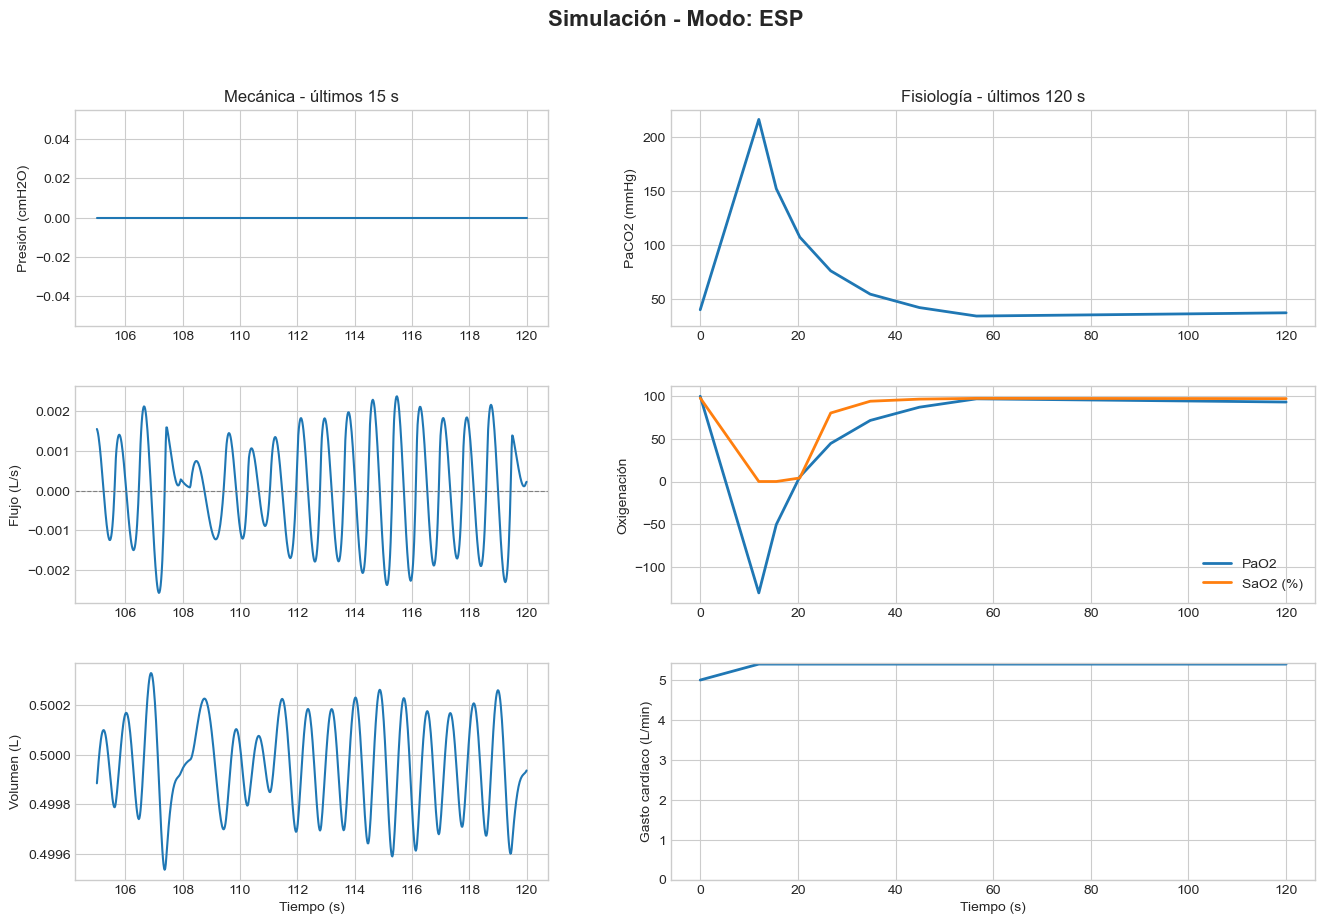

In [8]:
def ejecutar_simulacion_modo(modo: str):
    print(f"\n--- Iniciando simulación en modo: {modo} ---")

    paciente = Paciente(R1=5.0, C1=0.05, R2=5.0, C2=0.05)

    if modo == 'VCV':
        ventilador = Ventilador(modo='VCV', PEEP=5.0, Vt=0.450, Ti=1.0, fr=15.0)
        control = None
    elif modo == 'PCV':
        ventilador = Ventilador(modo='PCV', PEEP=5.0, P_driving=12.0, Ti=1.0, fr=15.0)
        control = None
    elif modo == 'ESP':
        ventilador = Ventilador(modo='ESP', PEEP=5.0, Ti=1.0, fr=15.0)
        control = ControlRespiratorio(PACO2_target=40.0, f_base=15.0, Gp=0.5, Gf=0.2, Gi=0.1)
    else:
        raise ValueError(f"Modo no soportado: {modo}")

    simulador = Simulador(paciente, ventilador, control)
    gases = IntercambioGases(ventilador, V_D=0.150, VCO2=200.0, R=0.8, FiO2=0.21, Pb=760.0)
    cardio = InteraccionCorazonPulmon(GC_base_L_min=5.0, k_sensibilidad=0.08, hb_g_dl=15.0)

    tiempo_total_s = 120.0
    dt_fisio = 3.0
    t_global = 0.0
    V0 = [0.0, 0.0]
    PACO2_actual = 40.0

    if modo == 'ESP':
        control.actualizar(PACO2_actual, dt=dt_fisio)
        ventilador.fr = control.frecuencia * 60.0
        ventilador.T_total = 60.0 / ventilador.fr

    hist_t_fis = [0.0]
    hist_PACO2 = [40.0]
    hist_PaO2 = [100.0]
    hist_SaO2 = [98.0]
    hist_GC = [5.0]

    hist_t_mec = []
    hist_Paw = []
    hist_Flujo = []
    hist_Vol = []

    while t_global < tiempo_total_s:
        if modo == 'ESP':
            control.actualizar(PACO2_actual, dt=dt_fisio)
            ventilador.fr = control.frecuencia * 60.0
            ventilador.T_total = 60.0 / ventilador.fr

        duracion_chunk = min(3.0 * ventilador.T_total, tiempo_total_s - t_global)
        n_puntos = max(60, int(np.ceil(duracion_chunk * 50)))
        t_eval = np.linspace(t_global, t_global + duracion_chunk, n_puntos)

        sol = solve_ivp(
            simulador._modelo_edo,
            [t_global, t_global + duracion_chunk],
            V0,
            t_eval=t_eval,
            method='RK45'
        )

        if not sol.success:
            raise RuntimeError(f"Falló solve_ivp en modo {modo}: {sol.message}")

        V0 = sol.y[:, -1]
        res_mec = simulador.procesar_resultados(sol.t, sol.y[0], sol.y[1])

        hist_t_mec.extend(res_mec['t'].tolist())
        hist_Paw.extend(res_mec['P_aw'].tolist())
        hist_Flujo.extend(res_mec['flow'].tolist())
        hist_Vol.extend(res_mec['Vt'].tolist())

        try:
            res_gases = gases.calcular(res_mec)
            nueva_PACO2 = res_gases['PACO2_mmHg']
        except ValueError:
            nueva_PACO2 = PACO2_actual + 2.0
            res_gases = {
                'VE_min': np.nan,
                'VA_min': np.nan,
                'PACO2_mmHg': nueva_PACO2,
                'PAO2_mmHg': gases.FiO2 * (gases.Pb - gases.PH2O) - (nueva_PACO2 / gases.R)
            }

        PACO2_actual = (0.3 * nueva_PACO2) + (0.7 * PACO2_actual)
        res_gases['PACO2_mmHg'] = PACO2_actual
        res_gases['PAO2_mmHg'] = gases.FiO2 * (gases.Pb - gases.PH2O) - (PACO2_actual / gases.R)

        res_cardio = cardio.calcular(res_mec, res_gases, ventilador)

        t_global += duracion_chunk
        hist_t_fis.append(t_global)
        hist_PACO2.append(PACO2_actual)
        hist_PaO2.append(res_cardio['PaO2_mmHg'])
        hist_SaO2.append(res_cardio['SaO2_percent'])
        hist_GC.append(res_cardio['GC_actual_L_min'])

    hist_t_mec = np.array(hist_t_mec)
    hist_Paw = np.array(hist_Paw)
    hist_Flujo = np.array(hist_Flujo)
    hist_Vol = np.array(hist_Vol)

    hist_t_fis = np.array(hist_t_fis)
    hist_PACO2 = np.array(hist_PACO2)
    hist_PaO2 = np.array(hist_PaO2)
    hist_SaO2 = np.array(hist_SaO2)
    hist_GC = np.array(hist_GC)

    ventana_mec = 15.0
    ventana_fis = 120.0

    mask_mec = hist_t_mec >= (hist_t_mec[-1] - ventana_mec)
    mask_fis = hist_t_fis >= (hist_t_fis[-1] - ventana_fis)

    graficar_escenario(
        modo,
        hist_t_mec[mask_mec], hist_Paw[mask_mec], hist_Flujo[mask_mec], hist_Vol[mask_mec],
        hist_t_fis[mask_fis], hist_PACO2[mask_fis], hist_PaO2[mask_fis], hist_SaO2[mask_fis], hist_GC[mask_fis]
    )


def graficar_escenario(modo, t_mec, Paw, Flujo, Vol, t_fis, PACO2, PaO2, SaO2, GC):
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 2, width_ratios=[1.1, 1.5], hspace=0.28, wspace=0.22)
    fig.suptitle(f'Simulación - Modo: {modo}', fontsize=16, fontweight='bold')

    ax_p = fig.add_subplot(gs[0, 0])
    ax_f = fig.add_subplot(gs[1, 0], sharex=ax_p)
    ax_v = fig.add_subplot(gs[2, 0], sharex=ax_p)

    ax_co2 = fig.add_subplot(gs[0, 1])
    ax_o2 = fig.add_subplot(gs[1, 1], sharex=ax_co2)
    ax_gc = fig.add_subplot(gs[2, 1], sharex=ax_co2)

    ax_p.plot(t_mec, Paw)
    ax_p.set_ylabel('Presión (cmH2O)')
    ax_p.set_title('Mecánica - últimos 15 s')

    ax_f.plot(t_mec, Flujo)
    ax_f.axhline(0, color='gray', linestyle='--', lw=0.8)
    ax_f.set_ylabel('Flujo (L/s)')

    ax_v.plot(t_mec, Vol)
    ax_v.set_ylabel('Volumen (L)')
    ax_v.set_xlabel('Tiempo (s)')

    ax_co2.plot(t_fis, PACO2, lw=2)
    ax_co2.set_ylabel('PaCO2 (mmHg)')
    ax_co2.set_title('Fisiología - últimos 120 s')

    ax_o2.plot(t_fis, PaO2, lw=2, label='PaO2')
    ax_o2.plot(t_fis, SaO2, lw=2, label='SaO2 (%)')
    ax_o2.set_ylabel('Oxigenación')
    ax_o2.legend()

    ax_gc.plot(t_fis, GC, lw=2)
    ax_gc.set_ylabel('Gasto cardíaco (L/min)')
    ax_gc.set_xlabel('Tiempo (s)')
    ax_gc.set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()


for modo_eval in ['VCV', 'PCV', 'ESP']:
    ejecutar_simulacion_modo(modo_eval)
